# 1. AR process

## 1.1 Simulation

In [1]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Parameters
np.random.seed(42)
n = 200
n_realizations = 5
phi1 = -0.6
phi2 = 0.5
sigma_eps = 1

In [3]:
# Recursive form:
# X_t = -phi1 X_{t-1} - phi2 X_{t-2} + eps_t
a1 = -phi1   # 0.6
a2 = -phi2   # -0.5

In [12]:
# Store simulations
X = np.zeros((n_realizations, n))

for r in range(n_realizations):
    eps = np.random.normal(0, sigma_eps, size=n)

    # initial values
    X[r, 0] = eps[0]
    X[r, 1] = a1 * X[r, 0] + eps[1]

    for t in range(2, n):
        X[r, t] = a1 * X[r, t-1] + a2 * X[r, t-2] + eps[t]

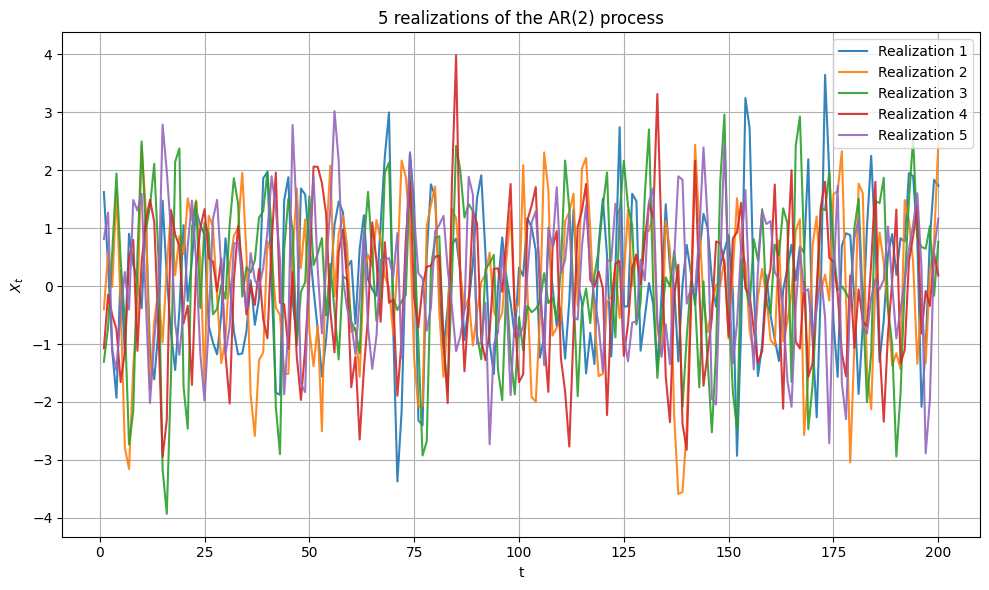

In [13]:
# Plot
plt.figure(figsize=(10, 6))
for r in range(n_realizations):
    plt.plot(range(1, n+1), X[r], label=f'Realization {r+1}', alpha=0.9)

plt.title('5 realizations of the AR(2) process')
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Second version using StatsModels ArmaProcess

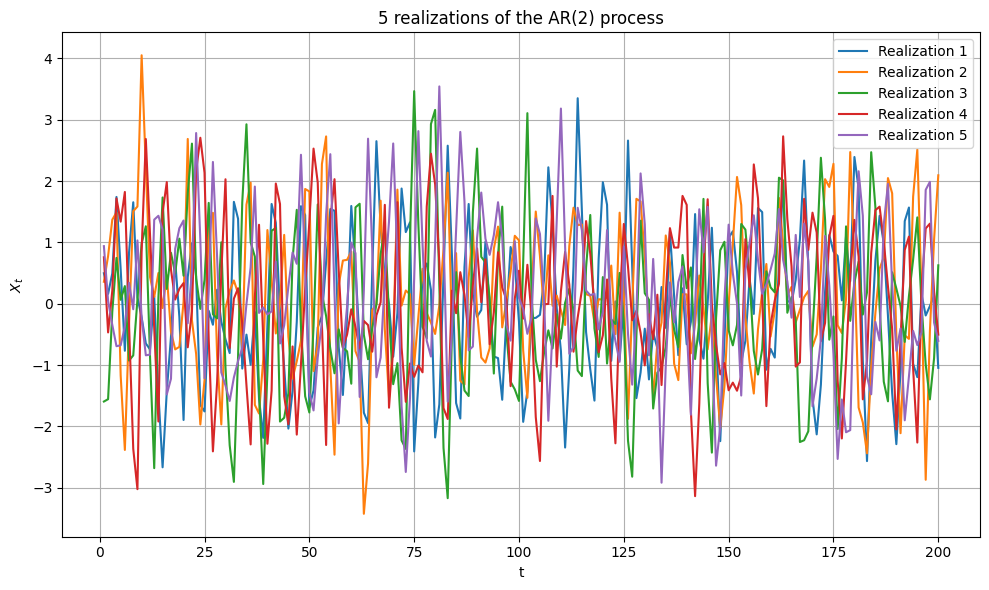

In [7]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

phi1 = -0.6
phi2 = 0.5
ar = np.array([1, phi1, phi2])   # because the model is X_t + phi1 X_{t-1} + phi2 X_{t-2} = eps_t
ma = np.array([1])

process = ArmaProcess(ar, ma)

n = 200
n_realizations = 5
X = np.array([process.generate_sample(nsample=n) for _ in range(n_realizations)])

plt.figure(figsize=(10, 6))
for r in range(n_realizations):
    plt.plot(range(1, n+1), X[r], label=f'Realization {r+1}')
plt.title('5 realizations of the AR(2) process')
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 1.2 ACF

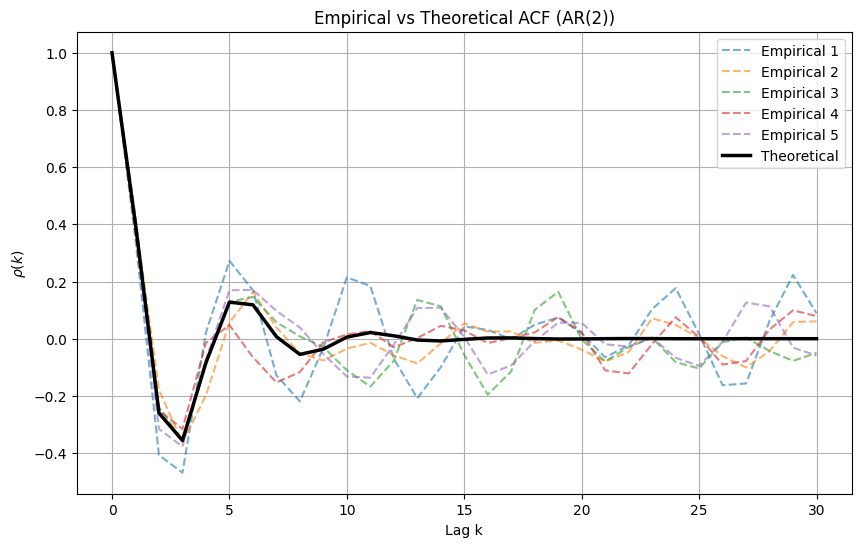

In [23]:
from statsmodels.tsa.stattools import acf

max_lag = 30

# ---- Theoretical ACF ----
rho = np.zeros(max_lag+1)
rho[0] = 1
rho[1] = -phi1/(1+phi2)

for k in range(2, max_lag+1):
    rho[k] = 0.6 * rho[k-1] - 0.5 * rho[k-2]

# ---- Empirical ACF ----
emp_acfs = []
for r in range(n_realizations):
    emp = acf(X[r], nlags=max_lag, fft=False)
    emp_acfs.append(emp)

emp_acfs = np.array(emp_acfs)

# ---- Plot ----
plt.figure(figsize=(10,6))

# plot empirical ACFs
for r in range(n_realizations):
    plt.plot(emp_acfs[r], alpha=0.6, linestyle='--', label=f'Empirical {r+1}')

# plot theoretical ACF
plt.plot(rho, color='black', linewidth=2.5, label='Theoretical')

plt.title('Empirical vs Theoretical ACF (AR(2))')
plt.xlabel('Lag k')
plt.ylabel(r'$\rho(k)$')
plt.legend()
plt.grid(True)
plt.show()

## 1.3-6 Trying different parameters

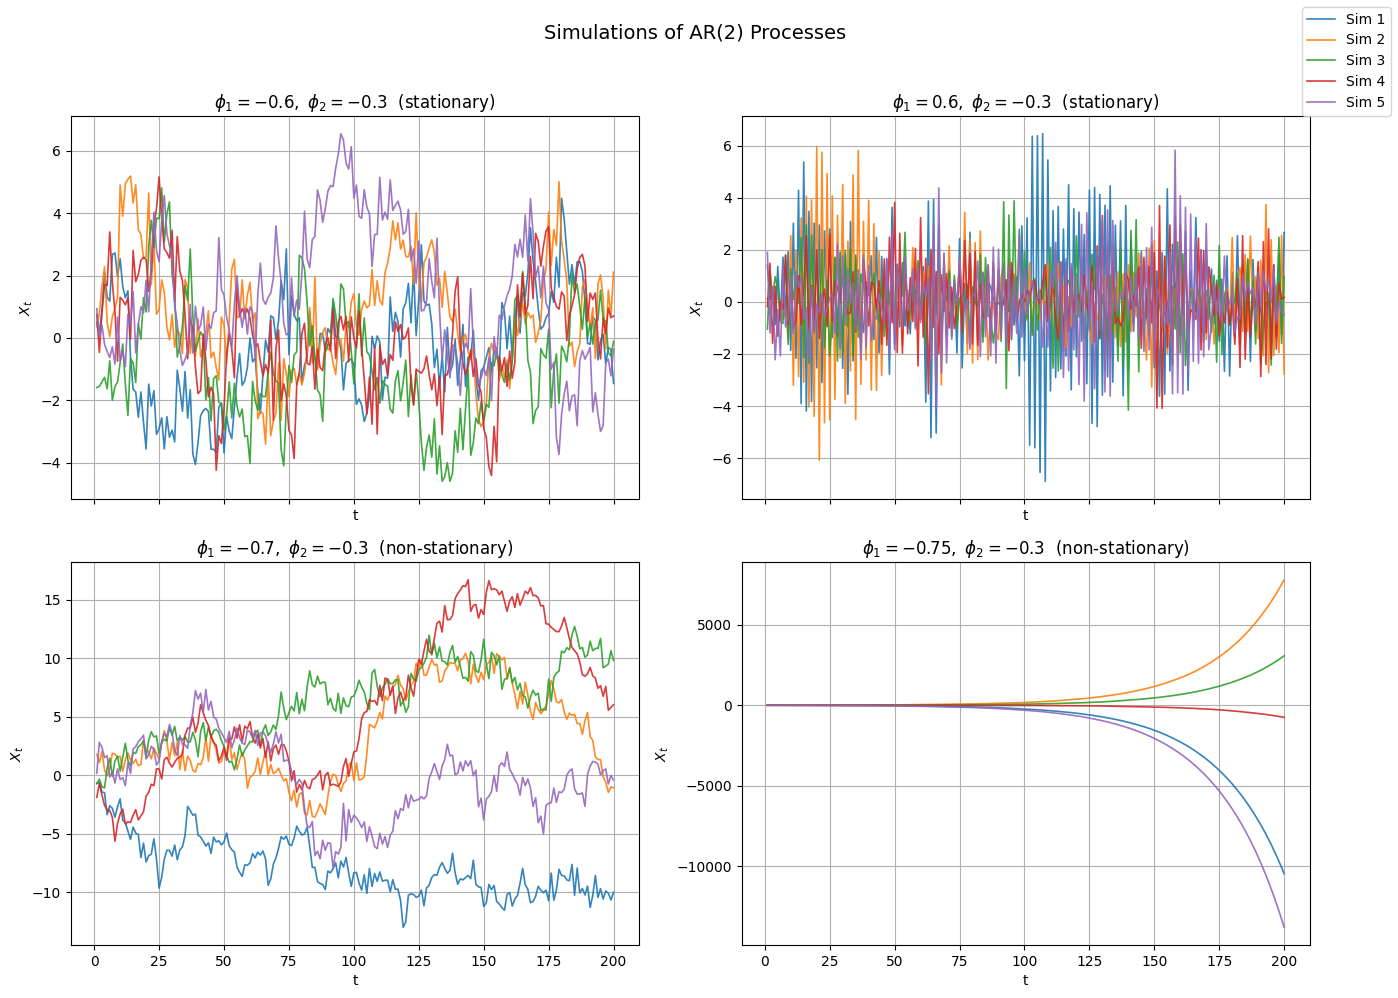

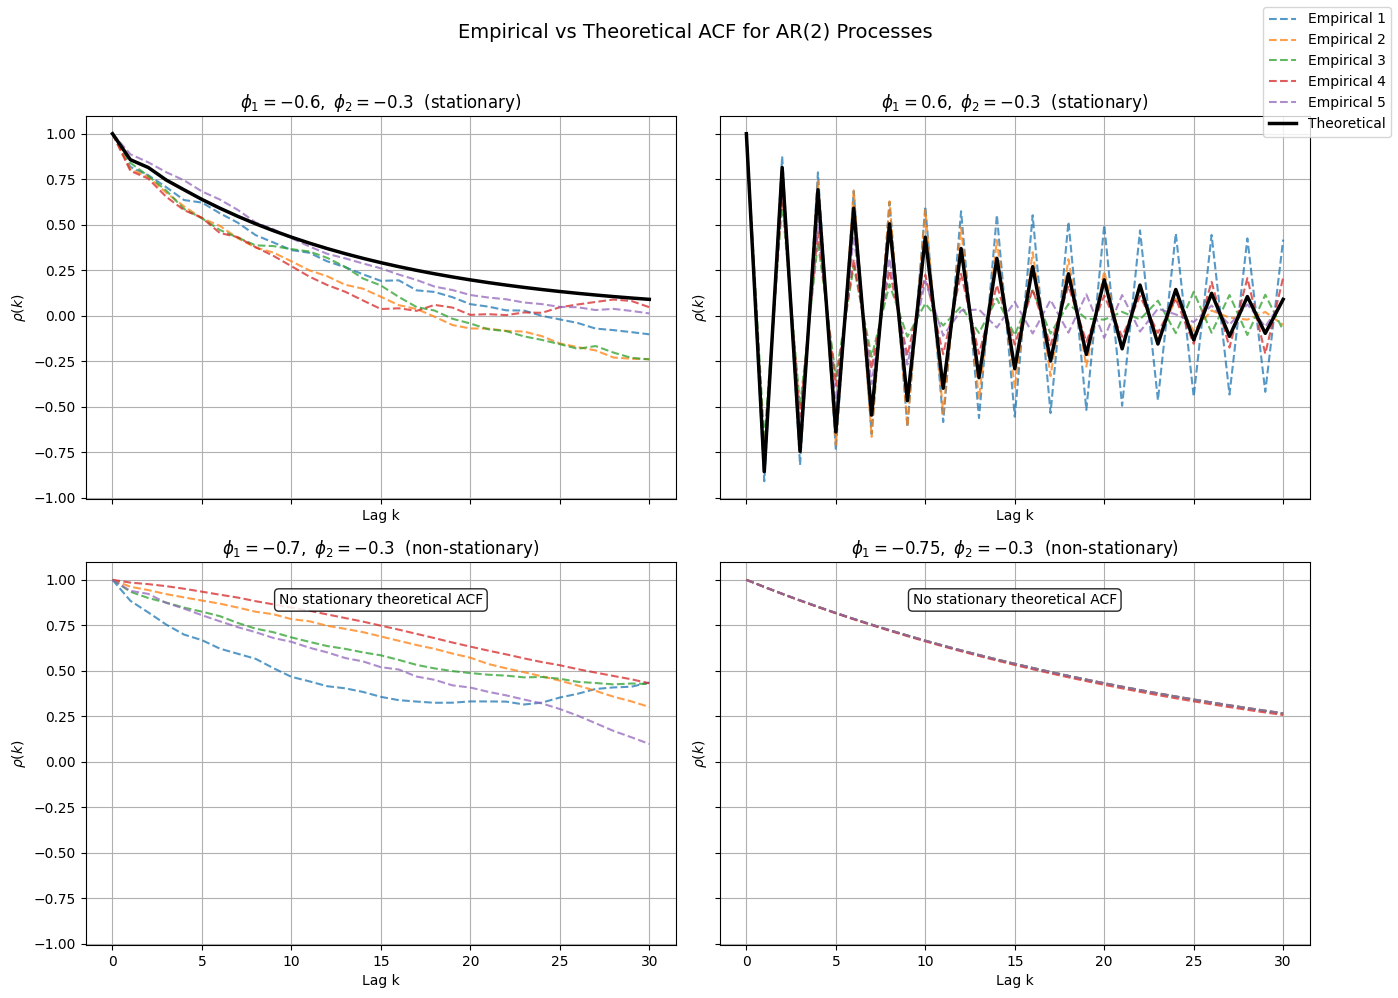

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# ============================================================
# Settings
# ============================================================
np.random.seed(42)

n = 200
n_realizations = 5
max_lag = 30
sigma_eps = 1

# Parameter sets: (phi1, phi2)
param_list = [
    (-0.6, -0.3),   # 1.3
    ( 0.6, -0.3),   # 1.4
    (-0.7, -0.3),   # 1.5
    (-0.75, -0.3)   # 1.6
]

# ============================================================
# Helper functions
# ============================================================

def simulate_ar2(phi1, phi2, n=200, n_realizations=5, sigma_eps=1):
    """
    Simulate AR(2):
        X_t + phi1 X_{t-1} + phi2 X_{t-2} = eps_t
    i.e.
        X_t = -phi1 X_{t-1} - phi2 X_{t-2} + eps_t
    """
    X = np.zeros((n_realizations, n))
    a1 = -phi1
    a2 = -phi2

    for r in range(n_realizations):
        eps = np.random.normal(0, sigma_eps, size=n)

        # simple initialization
        X[r, 0] = eps[0]
        X[r, 1] = a1 * X[r, 0] + eps[1]

        for t in range(2, n):
            X[r, t] = a1 * X[r, t-1] + a2 * X[r, t-2] + eps[t]

    return X


def is_stationary_ar2(phi1, phi2):
    """
    Stationarity check for
        phi(z) = 1 + phi1 z + phi2 z^2
    Stationary iff all roots satisfy |z| > 1
    """
    roots = np.roots([phi2, phi1, 1.0])   # phi2 z^2 + phi1 z + 1 = 0
    return np.all(np.abs(roots) > 1)


def theoretical_acf_ar2(phi1, phi2, max_lag=30):
    """
    Theoretical ACF for stationary AR(2):
        rho(0) = 1
        rho(1) = -phi1 / (1 + phi2)
        rho(k) = -phi1 rho(k-1) - phi2 rho(k-2),  k >= 2
    """
    rho = np.zeros(max_lag + 1)
    rho[0] = 1.0
    rho[1] = -phi1 / (1.0 + phi2)

    for k in range(2, max_lag + 1):
        rho[k] = -phi1 * rho[k-1] - phi2 * rho[k-2]

    return rho


# ============================================================
# Simulate all cases first
# ============================================================
all_simulations = {}
for phi1, phi2 in param_list:
    all_simulations[(phi1, phi2)] = simulate_ar2(
        phi1, phi2,
        n=n,
        n_realizations=n_realizations,
        sigma_eps=sigma_eps
    )

# ============================================================
# FIGURE 1: Simulations
# ============================================================
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes1 = axes1.flatten()

time = np.arange(1, n + 1)

for idx, (phi1, phi2) in enumerate(param_list):
    ax = axes1[idx]
    X = all_simulations[(phi1, phi2)]

    for r in range(n_realizations):
        ax.plot(time, X[r], linewidth=1.2, alpha=0.9, label=f'Sim {r+1}' if idx == 0 else None)

    stationary = is_stationary_ar2(phi1, phi2)
    status = "stationary" if stationary else "non-stationary"

    ax.set_title(rf'$\phi_1={phi1},\ \phi_2={phi2}$' + f'  ({status})')
    ax.set_xlabel('t')
    ax.set_ylabel(r'$X_t$')
    ax.grid(True)

handles1, labels1 = axes1[0].get_legend_handles_labels()
fig1.legend(handles1, labels1, loc='upper right')
fig1.suptitle('Simulations of AR(2) Processes', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

# ============================================================
# FIGURE 2: Empirical and Theoretical ACFs
# ============================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes2 = axes2.flatten()

lags = np.arange(0, max_lag + 1)

for idx, (phi1, phi2) in enumerate(param_list):
    ax = axes2[idx]
    X = all_simulations[(phi1, phi2)]

    # empirical ACFs
    for r in range(n_realizations):
        emp = acf(X[r], nlags=max_lag, fft=False)
        ax.plot(lags, emp, linestyle='--', alpha=0.75, label=f'Empirical {r+1}' if idx == 0 else None)

    # theoretical ACF only if stationary
    if is_stationary_ar2(phi1, phi2):
        rho = theoretical_acf_ar2(phi1, phi2, max_lag=max_lag)
        ax.plot(lags, rho, color='black', linewidth=2.5, label='Theoretical' if idx == 0 else None)
        subtitle = 'stationary'
    else:
        subtitle = 'non-stationary'
        ax.text(
            0.5, 0.92,
            'No stationary theoretical ACF',
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
        )

    ax.set_title(rf'$\phi_1={phi1},\ \phi_2={phi2}$' + f'  ({subtitle})')
    ax.set_xlabel('Lag k')
    ax.set_ylabel(r'$\rho(k)$')
    ax.grid(True)

handles2, labels2 = axes2[0].get_legend_handles_labels()
fig2.legend(handles2, labels2, loc='upper right')
fig2.suptitle('Empirical vs Theoretical ACF for AR(2) Processes', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

## 1.7 ACFs plots and Times Series Data plots
It is not sufficient to examine only the ACF. While the ACF provides useful information about the dependence structure of the process, it may be misleading in the presence of non-stationarity. The time series plot reveals important features such as trends, persistence, and potential instability that are not always evident from the ACF alone. Therefore, it is recommended to always inspect both the time series and the ACF to obtain a complete understanding of the data